# Trabalho 2

In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
import matplotlib.pyplot as plt
import numpy as np

from robotics.geometry import Pose, Angle, Segment
from robotics.robot import Robot

from robotics.distributions import GaussianDistribution
from robotics.maps import LandmarkMap, Landmark, ObstacleMap, DistanceField
from robotics.camera import Camera, DetectedFeature

from robotics.beam_range_finder import *

from robotics.learn_intrinsic_parameters import (
    generate_random_poses,
    generate_synthetic_dataset,
    learn_intrinsic_parameters
)
from robotics.likelihood_field import likelihood_field_range_finder_model

## Landmark Based Localization

### Map of Landmarks
A map of landmarks is basically a list, where each entry is associated with a set of coordinates for the landmark's position and a signature. A landmark $\mathcal{L}$, i.e. one entry in the map's list, is then defined as follows

$$\mathcal{L} = (x, y, s)$$

where $s$ denotes the landmarks unique signature.

>**Note:** the angle is not used in this implementation to simplify the algorithms and representations.

>**Note:** the singnature is equal to its index in the list of landmarks in this example of map, as this simplifies the algorithms in matching detected features with landmarks of the map. In reality the matching may include computer vision or other more complex and computationally intense algorithms

In [7]:
x_lims = [-5., 5.] 
y_lims = [-5., 5.]

m = LandmarkMap([
        Landmark(Pose(0, 0, Angle(0)), 0),
        Landmark(Pose(-3, 0, Angle(0)), 1),
        Landmark(Pose(0, -3, Angle(0)), 2),
    ],
    x_lims = x_lims,
    y_lims = y_lims 
)

# initial position of the robot
x0 = Pose(-3, -3, Angle.from_deg(55))

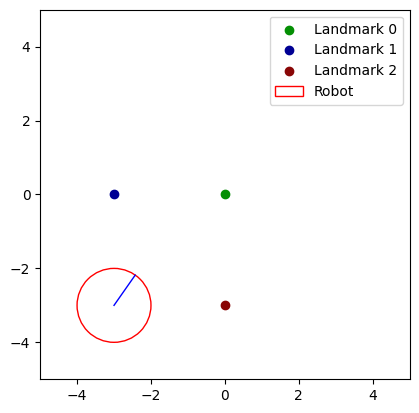

In [8]:
f = plt.figure()
ax = f.gca()

m.draw(ax, landmark_labels = True)
Robot(x0).draw(ax)

### Landmark Localizaition Probability Distribution
This algorithm computes the likelyhood of a given measurement for a pose in the space given a map of landmarks. This is done via the error between the actual measurement and the expected measurement at given location.


> **Note:** the `landmark_model_known_correspondence` has been adapted to take into consideration the orientation of the hypothesis $\theta_h$ by computing $$\hat{\phi} = \text{atan2}(dy, dx) - \theta_h$$ instead of simply computing $$\hat{\phi} = \text{atan2}(dy, dx)$$. If the subrtaction of $\theta_h$ is ommited, it is implicitly assumed that the hypothesis has a zero orientation, and the results will only be meaningfull if the robot took the measurement with zero orientation.

In [9]:
def landmark_model_known_correspondence(feature: DetectedFeature, correspondence: int, x_hypothesis: Pose, map: LandmarkMap, sigmas = [0.1, 0.1, 0.1]):
    [sigma_r, sigma_phi, sigma_s] = sigmas

    l = map.landmarks[correspondence]
    m_x, m_y, m_s = l.pos.x, l.pos.y, l.signature

    dx = m_x - x_hypothesis.x
    dy = m_y - x_hypothesis.y

    r_hat = np.sqrt(dx**2 + dy**2)
    phi_hat = Angle.atan2(dy, dx) - x_hypothesis.th

    return (
        GaussianDistribution(sigma_r**2).prob(feature.r - r_hat)
        * GaussianDistribution(sigma_phi**2).prob((feature.phi - phi_hat).rad) 
        * GaussianDistribution(sigma_s**2).prob(feature.s - m_s)
    )

To better better understand what is commputed and how the algorithm's parameters influence the outcome, three different cases are considered.

In [10]:
def plotLandmarkMeasurmentProbabilityDistribution(
        ax: plt.Axes, 
        fs: list[DetectedFeature],
        cs: list[int],
        m: LandmarkMap,
        sigmas: tuple[float, float, float] = (0.1, 0.1, 0.1), 
        resolution: float = 0.08, 
        angular_resolution: float = 10,
        x_interval: list[float, float] = [-5., 5.], 
        y_interval: list[float, float] = [-5., 5.],
        hypothesys_th_offset: Angle = Angle(0)
    ):

    #Draw probability distribution
    nx = int((x_interval[1] -  x_interval[0] + resolution) / resolution)
    ny = int((y_interval[1] -  y_interval[0] + resolution) / resolution)

    probability_distribution =  np.zeros((ny, nx))
    for x_idx, x in enumerate(np.linspace(x_interval[0], x_interval[1], num = nx)):
        for y_idx, y in enumerate(np.linspace(y_interval[0], y_interval[1], num = ny)):

            th = hypothesys_th_offset.deg
            while th < 360 + hypothesys_th_offset.deg:
                probability = 1

                x_hypothesis = Pose(x, y, Angle.from_deg(th))

                for f, c in zip(fs, cs):
                    probability *= landmark_model_known_correspondence(f, c, x_hypothesis, m, sigmas)
                
                probability_distribution[y_idx, x_idx] += probability

                th += angular_resolution

    ax.imshow(probability_distribution, cmap='Blues', extent=[x_interval[0], x_interval[1], y_interval[0], y_interval[1]], origin='lower')

def plotExperiment1(ax: plt.Axes, m: LandmarkMap, x0: Pose, sigma_r: float = 0.1, sigma_phi: float = 0.1):
    r = Robot(x0)
    c = Camera(Pose(0,0,Angle(0)),robot_pose=r.pos, field_of_veiw=Angle.from_deg(30))
    c.getReading(m,detection_noise=False)

    m.draw(ax)
    r.draw(ax)
    c.draw(ax, draw_sensor_readings=True)

    plotLandmarkMeasurmentProbabilityDistribution(ax, c.reading['features'], c.reading['correspondences'], m, hypothesys_th_offset = r.pos.th, angular_resolution = 360, sigmas=[sigma_r, sigma_phi, 0.1], x_interval=x_lims, y_interval=y_lims)

def plotExperiment2(ax: plt.Axes, m: LandmarkMap, x0: Pose, fov: Angle, sigmas = [0.5,0.5,0.1]):
    r = Robot(x0)
    c = Camera(Pose(0,0,Angle(0)),robot_pose=r.pos, field_of_veiw=fov)
    c.getReading(m,detection_noise=False)

    m.draw(ax)
    r.draw(ax)
    c.draw(ax, draw_sensor_readings=True)

    plotLandmarkMeasurmentProbabilityDistribution(ax, c.reading['features'], c.reading['correspondences'], m, hypothesys_th_offset = r.pos.th, angular_resolution = 360, sigmas=sigmas, x_interval=x_lims, y_interval=y_lims)

def plotExperiment3(ax: plt.Axes, m: LandmarkMap, x0: Pose, fov: Angle, sigmas = [0.5,0.5,0.1]):
    r = Robot(x0)
    c = Camera(Pose(0,0,Angle(0)),robot_pose=r.pos, field_of_veiw=fov)
    c.getReading(m,detection_noise=False)

    m.draw(ax)
    r.draw(ax)
    c.draw(ax, draw_sensor_readings=True)

    plotLandmarkMeasurmentProbabilityDistribution(ax, c.reading['features'], c.reading['correspondences'], m, angular_resolution = 10, sigmas=sigmas, x_interval=x_lims, y_interval=y_lims)

#### Example 1.
In this example we plot the probability distribution for one detected landmark, assuming that the orientation of the robot is known. Different valuse for the parameters $\sigma_r$ and $\sigma_{\phi}$ are tested to display their influence on the probability distribution. 

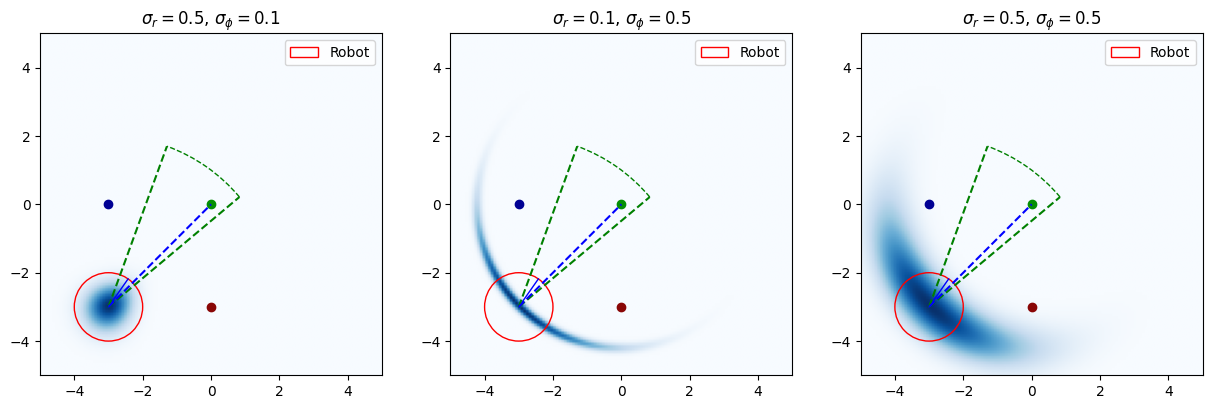

In [11]:
f = plt.figure(figsize=(15,5))

ax1 = plt.subplot(1,3, 1)
ax1.set_title("$\\sigma_r = 0.5$, $\\sigma_{\\phi} = 0.1$")
plotExperiment1(ax1, m, x0, sigma_r= 0.5)

ax2 = plt.subplot(1,3, 2)
ax2.set_title("$\\sigma_r = 0.1$, $\\sigma_{\\phi} = 0.5$")
plotExperiment1(ax2, m, x0, sigma_phi=0.5)

ax3 = plt.subplot(1,3, 3)
ax3.set_title("$\\sigma_r = 0.5$, $\\sigma_{\\phi} = 0.5$")
plotExperiment1(ax3, m, x0, sigma_phi=0.5, sigma_r=0.5)

#### Example 2
In this example we plot the probability distribution for an increasing number of detected landmarks assuming that we know the orientation of the robot at the time of measuremnt. This allows us to reduce/focus the region where the robot is located with high probablilty. In other words, the more landmarks are detected the less ambiguity/possibilities exist for that configuration of position-to-landmarks measurements.

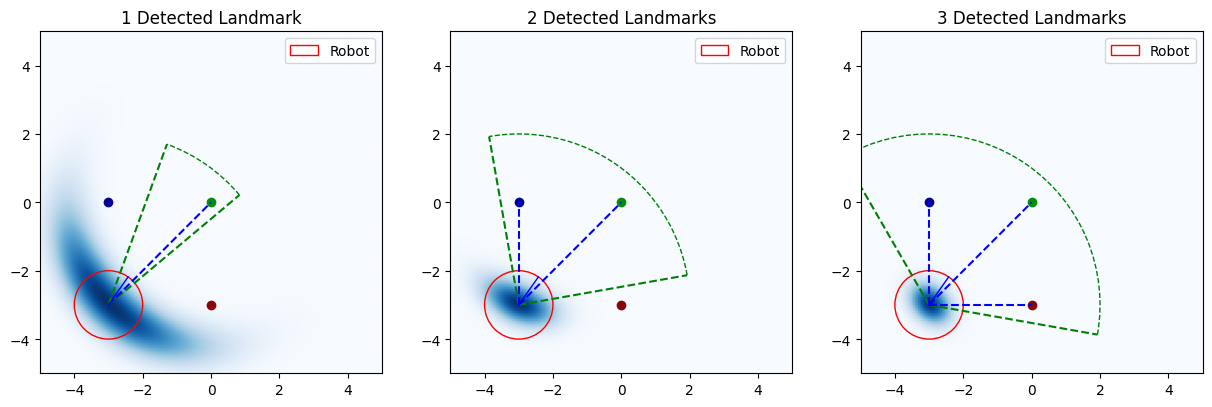

In [12]:
f = plt.figure(figsize=(15,5))

ax1 = plt.subplot(1,3, 1)
ax1.set_title("1 Detected Landmark")
plotExperiment2(ax1, m, x0, fov=Angle.from_deg(30))

ax2 = plt.subplot(1,3, 2)
ax2.set_title("2 Detected Landmarks")
plotExperiment2(ax2, m, x0, fov=Angle.from_deg(90))

ax3 = plt.subplot(1,3, 3)
ax3.set_title("3 Detected Landmarks")
plotExperiment2(ax3, m, x0, fov=Angle.from_deg(130))

#### Example 3
If a know orientation can not be assumed, a sweep across the range $\theta_h \in[0:360[$ of possible orientations must be performed, to find likely positions. However, this imples that with a single landmark we cannot infere a single point as possible location for the robot, instead we find that the most likely position is equally likely anywhere on the circle at the measured distance from the landmark. This approach is not only less precise, but also computationally more intense due to the unknown orientation.

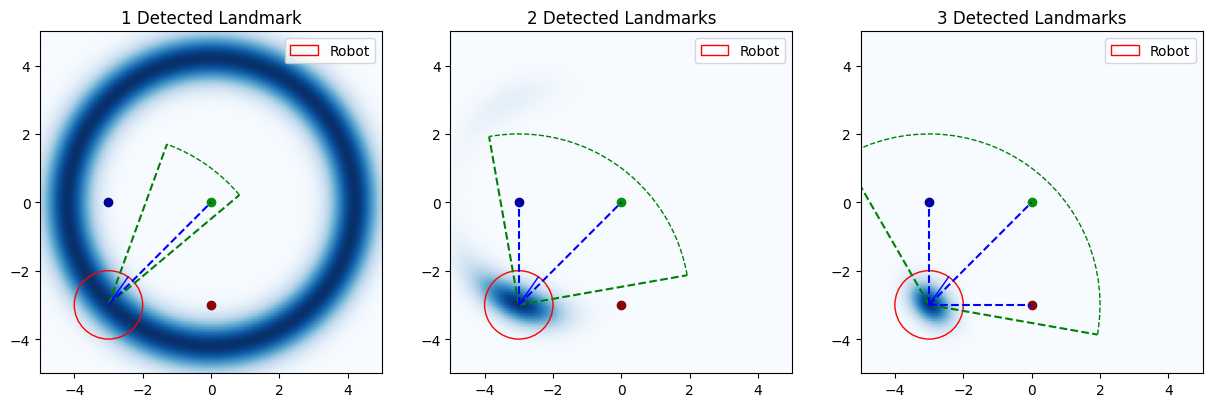

In [13]:
f = plt.figure(figsize=(15,5))

ax1 = plt.subplot(1,3, 1)
ax1.set_title("1 Detected Landmark")
plotExperiment3(ax1, m, x0, fov=Angle.from_deg(30))

ax2 = plt.subplot(1,3, 2)
ax2.set_title("2 Detected Landmarks")
plotExperiment3(ax2, m, x0, fov=Angle.from_deg(90))

ax3 = plt.subplot(1,3, 3)
ax3.set_title("3 Detected Landmarks")
plotExperiment3(ax3, m, x0, fov=Angle.from_deg(130))

### Landmark Localization Sample Distribution
Alternatively to estimate a region of likely positions from which a measurment could originate, a distribution of samples can be generated, similarly as we have already seen with the displacement models (Odometry Model and Velocity Model). After generating the samples we can see potential positions of the robot. Regions where the number of samples is higher indicates a higher likelyhood for the robot to be in that region at the time of the measurement. This can be seen better with a 2D histogramm, plotted in the case of the second experiment, where the highest count is more difficult to spot.

In [14]:
def sample_landmark_model_known_correspondence(feature: DetectedFeature, correspondence: int, map: LandmarkMap, sigmas = [0.1, 0.1]):
    [sigma_r, sigma_phi, sigma_s] = sigmas

    l = map.landmarks[correspondence]
    m_x, m_y = l.pos.x, l.pos.y

    gamma_hat = Angle(np.random.rand() * np.pi * 2)
    r_hat = feature.r + GaussianDistribution(sigma_r**2).sample()
    phi_hat = feature.phi + Angle(GaussianDistribution(sigma_phi**2).sample())

    return Pose(
        m_x + r_hat * gamma_hat.cos,
        m_y + r_hat * gamma_hat.sin,
        gamma_hat - Angle(np.pi) - phi_hat
    )

For the samples, as opposed to the probability distrinution, the orientation of the robot is not considered at all. This is because they are generated from the measurements, in a sense backwards. Indeed, to the measeurement radius and bearing a noise ($\delta_r$ and $\delta_\phi$ respectively) is added $$\hat r = r_z + \delta_r$$ and $$\hat\phi = \phi_z + \delta_\phi$$ then the correspondence is used to "project the sample back" at its measurement location. In doing so the population of samples is placed successfully in the region where a measurement $z$ could be more likely, effectively indicating potential locations for the robot. If then the sample density in a given location is computed, e.g. by a 2D histogramm, the most likely position can be extracted by simply maximising the sample density (see [Example 5](#example-5)). 

In [15]:
def plotLandmarkMeasurmentSampleDistribution(
        ax: plt.Axes, 
        fs: list[DetectedFeature],
        cs: list[int],
        m: LandmarkMap,
        sigmas: tuple[float, float, float] = (0.1, 0.1, 0.1), 
        n_samples: int = 1000, 
        x_interval: list[float, float] = [-5., 5.], 
        y_interval: list[float, float] = [-5., 5.],
    ):

    samples = []

    for f, c in zip(fs, cs):
        for _ in range(n_samples):
            sample = sample_landmark_model_known_correspondence(f, c, m, sigmas)
            samples.append([sample.x, sample.y])
            
            ax.scatter(sample.x, sample.y, color="#184eb321", marker='.')
    
    ax.set_xlim(x_interval[0], x_interval[1])
    ax.set_ylim(y_interval[0], y_interval[1])

    return samples

def plotSampleExperiment1(ax: plt.Axes, m: LandmarkMap, x0: Pose, sigma_r: float = 0.1, sigma_phi: float = 0.1):
    r = Robot(x0)
    c = Camera(Pose(0,0,Angle(0)),robot_pose=r.pos, field_of_veiw=Angle.from_deg(30))
    c.getReading(m,detection_noise=False)

    m.draw(ax)
    r.draw(ax)
    c.draw(ax, draw_sensor_readings=True)

    return plotLandmarkMeasurmentSampleDistribution(ax, c.reading['features'], c.reading['correspondences'], m, sigmas=[sigma_r, sigma_phi, 0.1], x_interval=x_lims, y_interval=y_lims)

def plotSampleExperiment2(ax: plt.Axes, m: LandmarkMap, x0: Pose, fov: Angle, sigmas = [0.2,0.2,0.1]):
    r = Robot(x0)
    c = Camera(Pose(0,0,Angle(0)),robot_pose=r.pos, field_of_veiw=fov)
    c.getReading(m,detection_noise=False)

    m.draw(ax)
    r.draw(ax)
    c.draw(ax, draw_sensor_readings=True)

    return plotLandmarkMeasurmentSampleDistribution(ax, c.reading['features'], c.reading['correspondences'], m, sigmas=sigmas, x_interval=x_lims, y_interval=y_lims)


In [16]:
#2D hist. computation utils
def round_to_resolution(x: np.ndarray, r: float):
  return np.round(x / r) * r

def plot2Dhist(ax: plt.Axes, samples, resolution = 0.5):
    rounded_samples = round_to_resolution(samples, resolution)

    #create image for 2D histogram
    x_min, x_max = x_lims
    y_min, y_max = y_lims

    nx = int((x_max - x_min) / resolution + 1)
    ny = int((y_max - y_min) / resolution + 1)

    img = np.zeros((ny, nx), dtype=float)

    #compute histogram
    ny, nx = img.shape
    for x in range(nx):
        for y in range(ny):
            xx, yy = x * resolution + x_lims[0], y * resolution + y_lims[0]

            count = np.sum((rounded_samples[:, 0] == xx) & (rounded_samples[:, 1] == yy))
            img[y, x] = count

    #get best estimated position
    best_pos = np.unravel_index(np.argmax(img, axis=None), img.shape)
    best_x = best_pos[1] * resolution + x_lims[0]
    best_y = best_pos[0] * resolution + y_lims[0]

    ax.set_xlim(x_lims)
    ax.set_ylim(y_lims)

    ax.imshow(img / np.max(img), extent=(x_lims[0], x_lims[1], y_lims[0], y_lims[1]), origin='lower', cmap='Blues', alpha=0.5, zorder=0)

    return Pose(best_x, best_y, Angle(0))

#### Example 4
This example shows the influence of the parameters $\sigma_r$ and $\sigma_{\phi}$ on the deistribution of samples, note that the bearing has little effective influence on the sample distribution.

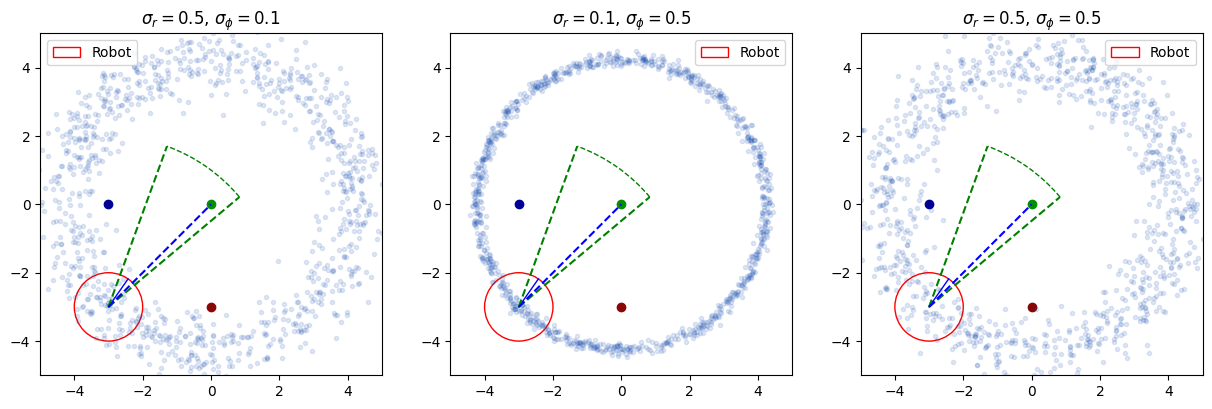

In [17]:
f = plt.figure(figsize=(15,5))

ax1 = plt.subplot(1,3, 1)
ax1.set_title("$\\sigma_r = 0.5$, $\\sigma_{\\phi} = 0.1$")
_ = plotSampleExperiment1(ax1, m, x0, sigma_r= 0.5)

ax2 = plt.subplot(1,3, 2)
ax2.set_title("$\\sigma_r = 0.1$, $\\sigma_{\\phi} = 0.5$")
_= plotSampleExperiment1(ax2, m, x0, sigma_phi=0.5)

ax3 = plt.subplot(1,3, 3)
ax3.set_title("$\\sigma_r = 0.5$, $\\sigma_{\\phi} = 0.5$")
_= plotSampleExperiment1(ax3, m, x0, sigma_phi=0.5, sigma_r=0.5)

#### Example 5
Here the superposition of several populations - one per measurement - yields a more accurate estimate of the likelyhood distribution, and ultimately of the robots location. The effectiveness of the illustrated method might be questioned, and the algorithms efficiency might be questionable for real world applications.

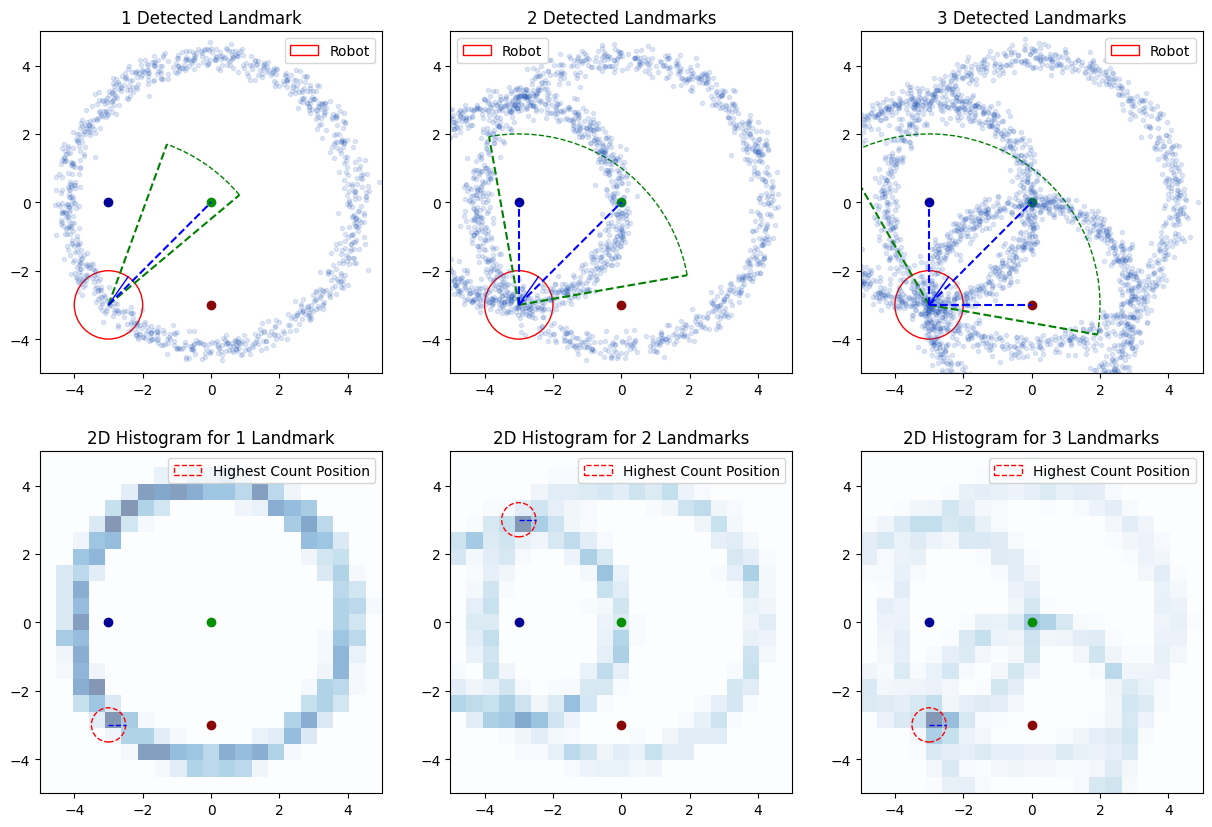

In [18]:
f = plt.figure(figsize=(15,10))

ax1 = plt.subplot(2,3, 1)
ax1.set_title("1 Detected Landmark")
s1 = plotSampleExperiment2(ax1, m, x0, fov=Angle.from_deg(30))

ax2 = plt.subplot(2,3, 2)
ax2.set_title("2 Detected Landmarks")
s2 = plotSampleExperiment2(ax2, m, x0, fov=Angle.from_deg(90))

ax3 = plt.subplot(2,3, 3)
ax3.set_title("3 Detected Landmarks")
s3 = plotSampleExperiment2(ax3, m, x0, fov=Angle.from_deg(130))

ax4 = plt.subplot(2,3, 4)
ax4.set_title("2D Histogram for 1 Landmark")
m.draw(ax4)
best_pos = plot2Dhist(ax4, samples=np.array(s1))
Robot(best_pos, name="Highest Count Position").draw(ax4, r=0.5, linestyles=['--','--'])

ax5 = plt.subplot(2,3, 5)
ax5.set_title("2D Histogram for 2 Landmarks")
m.draw(ax5)
best_pos = plot2Dhist(ax5, samples=np.array(s2))
Robot(best_pos, name="Highest Count Position").draw(ax5, r=0.5, linestyles=['--','--'])

ax6 = plt.subplot(2,3, 6)
ax6.set_title("2D Histogram for 3 Landmarks")
m.draw(ax6)
best_pos = plot2Dhist(ax6, samples=np.array(s3))
Robot(best_pos, name="Highest Count Position").draw(ax6, r=0.5, linestyles=['--','--'])

The simulations demonstrate that a single landmark observation provides limited information about the robot's position, resulting in a significant ambiguity represented by an approximately circular distribution of possible poses around the observed landmark. As additional landmarks are detected, independent pose distributions are generated for each observation and superimposed in the same spatial representation, producing more specific regions of overlap. The 2D histogram provides a convenient way to identify the region with the highest concentration of samples and, consequently, to obtain an estimate of the robot's most likely position. Overall, the results illustrate how landmark observations can be used to constrain the robot's possible poses and improve position estimation.


## Beam Range Finder Model

The **Beam Range Finder Model** describes how a range sensor, such as a laser scanner, is expected to produce measurements given the robot pose $x_t$ and the map $m$. Its main objective is to compute the **likelihood of an observed laser scan** under a candidate robot pose:

$$
\boxed{
p(z_t \mid x_t,m)
}
$$

The model combines the expected measurement obtained from the map with four possible types of sensor behavior: **correct measurements (`hit`)**, **unexpected short measurements (`short`)**, **maximum-range measurements (`max`)**, and **random measurements (`rand`)**.

For each beam $k$, the expected range $z_t^{k*}$ is first obtained through **ray casting**. The observed measurement $z_t^k$ is then evaluated using the probabilistic sensor model:

$$
p(z_t^k\mid x_t,m)
=
z_{\mathrm{hit}}p_{\mathrm{hit}}
+
z_{\mathrm{short}}p_{\mathrm{short}}
+
z_{\mathrm{max}}p_{\mathrm{max}}
+
z_{\mathrm{rand}}p_{\mathrm{rand}}.
$$

Assuming that the individual beams are conditionally independent given the robot pose and map, the likelihood of the complete scan is obtained by multiplying the probabilities of all $K$ beams:

$$
\boxed{
p(z_t\mid x_t,m)
=
\prod_{k=1}^{K}
p(z_t^k\mid x_t,m)
}
$$

### Algorithm

The overall procedure can be summarized by the following pseudocode:

```text
Algorithm beam_range_finder_model(z_t, x_t, m):

    q = 1

    for k = 1 to K do

        compute z_t^{k*} for the measurement z_t^k
        using ray casting

        p =
            z_hit  · p_hit(z_t^k | x_t, m)
          + z_short · p_short(z_t^k | x_t, m)
          + z_max  · p_max(z_t^k | x_t, m)
          + z_rand · p_rand(z_t^k | x_t, m)

        q = q · p

    return q
```
For each candidate pose, the algorithm therefore performs **ray casting for every beam**, obtaining the expected range $z_t^{k*}$. The observed measurement is then compared with this expected value through the four probabilistic components.

The resulting likelihood indicates how well the complete laser scan is explained by the candidate pose and the map. Therefore, by evaluating this likelihood over a set of possible poses, we can construct a **likelihood distribution over the robot's position**.

The complete process can be summarized as:
$$\boxed{
    x_t
    \rightarrow
    z_t^{k*}
    \rightarrow
    p(z_t^k \mid x_t,m)
    \rightarrow
    p(z_t \mid x_t,m)
}$$





In [19]:
def create_features(
    n_beams: int = 8,
    z_max: float = 10.0,
    sigma_sensor: float = 0.2,
    seed: int | None = 42,
    x_true=(0.0, 0.0),
    theta_true=0.0
):
    pose_true = Pose(
        x_true[0],
        x_true[1],
        Angle(theta_true)
    )
    rng = np.random.default_rng(seed)
    x_values = np.linspace(-5, 5, 100)
    y_values = np.linspace(-5, 5, 100)


    obstacle_map = ObstacleMap(
        [
            Segment((-5, 5), (5, 5)),
            Segment((5, -5), (5, 5)),
            Segment((-5, 5), (-5, -4)),

            Segment((-5, -4), (-4, -4)),
            Segment((-4, -5), (-4, -4)),
            Segment((-5, -1), (-3, -1)),

            Segment((-3, 2.5), (-1, 2.5)),
            Segment((-2, 1.5), (-2, 3.5)),
            Segment((0.5, 5), (2, 1)),

            Segment((3, 3), (3, 5)),
            Segment((4, 1), (5, 1)),
            Segment((-1, -1), (0, -1)),

            Segment((0, -1), (0, -5)),
            Segment((1.5, -1.5), (3.5, -3.5)),
            Segment((1.5, -3.5), (3.5, -1.5)),
        ],
        x_lims=(-5, 5),
        y_lims=(-5, 5)
    )


    beam_angles = (
        np.arange(n_beams)
        * 2 * np.pi
        / n_beams
    )

    z_expected = []
    z = []

    for beam_angle in beam_angles:

        z_hat = obstacle_map.ray_cast(
            Pose(pose_true.x, pose_true.y, pose_true.th.rad + beam_angle),
            max_range=z_max
        )

        z_expected.append(z_hat)

        measurement = (
            z_hat
            + rng.normal(
                0,
                sigma_sensor
            )
        )

        measurement = np.clip(
            measurement,
            0,
            z_max
        )

        z.append(measurement)

    return (
        obstacle_map,
        beam_angles,
        z_expected,
        z,
        x_values,
        y_values,
        pose_true
    )

In [26]:
def build_probability_map(
    obstacle_map,
    beam_angles,
    z,
    x_values,
    y_values,
    z_max,
    sigma_hit,
    lambda_short,
    z_hit,
    z_short,
    z_max_weight,
    z_rand
):
    probability_map = np.zeros(
        (len(y_values), len(x_values))
    )

    for i, x in enumerate(x_values):
        for j, y in enumerate(y_values):
            x_hypothesis = Pose(
                x,
                y,
                Angle(0)
            )

            probability_map[j, i] = beam_range_finder_model(
                z=z,
                x=x_hypothesis,
                obstacle_map=obstacle_map,
                z_max=z_max,
                z_hit=z_hit,
                z_short=z_short,
                z_max_weight=z_max_weight,
                z_rand=z_rand,
                sigma_hit=sigma_hit,
                lambda_short=lambda_short,
                beam_angles=beam_angles
            )

    return probability_map

In [27]:
def draw_probability_map_ax(
    ax,
    probability_map,
    x_values,
    y_values,
    obstacle_map,
    pose_true=None,
    title=""
):
    image = ax.imshow(
        probability_map,
        extent=[
            x_values.min(),
            x_values.max(),
            y_values.min(),
            y_values.max()
        ],
        origin="lower",
        aspect="equal",
        cmap="viridis",
        alpha=0.85
    )

    # Obstacles
    for segment in obstacle_map.segments:

        x1, y1 = segment.p1.x, segment.p1.y
        x2, y2 = segment.p2.x, segment.p2.y

        ax.plot(
            [x1, x2],
            [y1, y2],
            color="black",
            linewidth=2
        )

    # True pose
    if pose_true is not None:

        ax.scatter(
            pose_true.x,
            pose_true.y,
            marker="x",
            color="red",
            s=100,
            linewidths=2.5,
            zorder=3
        )

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    return image

In [28]:
def compute_beam_probability_map(
    n_beams,
    robot_position=(0.0, 0.0),
    theta=0.0,
    z_max=10.0,
    sigma_sensor=0.2,
    seed=42
):
    (obstacle_map, beam_angles, z_expected, z, x_values, y_values, pose_true) = create_features(
        n_beams=n_beams,
        z_max=z_max,
        sigma_sensor=sigma_sensor,
        seed=seed,
        x_true=robot_position,
        theta_true=theta
    )

    probability_map = build_probability_map(
        obstacle_map=obstacle_map,
        beam_angles=beam_angles,
        z=z,
        x_values=x_values,
        y_values=y_values,
        z_max=z_max,
        z_hit=z_hit,
        z_short=z_short,
        z_max_weight=z_max_weight,
        z_rand=z_rand,
        sigma_hit=sigma_hit,
        lambda_short=lambda_short
    )

    return (
        probability_map,
        obstacle_map,
        x_values,
        y_values,
        pose_true
    )

In [29]:
z_max = 10.0
z_hit = 0.7

z_short = 0.1
z_max_weight = 0.1
z_rand = 0.1

sigma_hit = 0.2
lambda_short = 1.0
sigma_sensor = 0.2

def plot_beam_range_finder_experiments(
    theta,
    beam_experiments=(1, 3, 6),
    robot_positions=(
        (-2.5, -2.5),
        (0.0, 0.0),
        (2.5, 2.5)
    ),
    z_max=10.0,
    sigma_sensor=sigma_sensor,
    seed=42
):


    fig, axes = plt.subplots(
        2,
        3,
        figsize=(15, 9)
    )

    for ax, n_beams in zip(axes[0], beam_experiments):
        (
            probability_map,
            obstacle_map,
            x_values,
            y_values,
            pose_true
        ) = compute_beam_probability_map(
            n_beams=n_beams,
            robot_position=(0.0, 0.0),
            theta=theta,
            z_max=z_max,
            sigma_sensor=sigma_sensor,
            seed=seed
        )

        draw_probability_map_ax(
            ax=ax,
            probability_map=probability_map,
            x_values=x_values,
            y_values=y_values,
            obstacle_map=obstacle_map,
            pose_true=pose_true,
            title=f"{n_beams} laser beam(s)"
        )

    for ax, position in zip(axes[1], robot_positions):

        (
            probability_map,
            obstacle_map,
            x_values,
            y_values,
            pose_true
        ) = compute_beam_probability_map(
            n_beams=4,
            robot_position=position,
            theta=theta,
            z_max=z_max,
            sigma_sensor=sigma_sensor,
            seed=seed
        )

        draw_probability_map_ax(
            ax=ax,
            probability_map=probability_map,
            x_values=x_values,
            y_values=y_values,
            obstacle_map=obstacle_map,
            pose_true=pose_true,
            title=(
                f"4 beams — "
                f"pose ({pose_true.x:.1f}, "
                f"{pose_true.y:.1f})"
                f" at {pose_true.th.deg:.1f}°"
            )
        )

    plt.tight_layout()
    plt.show()

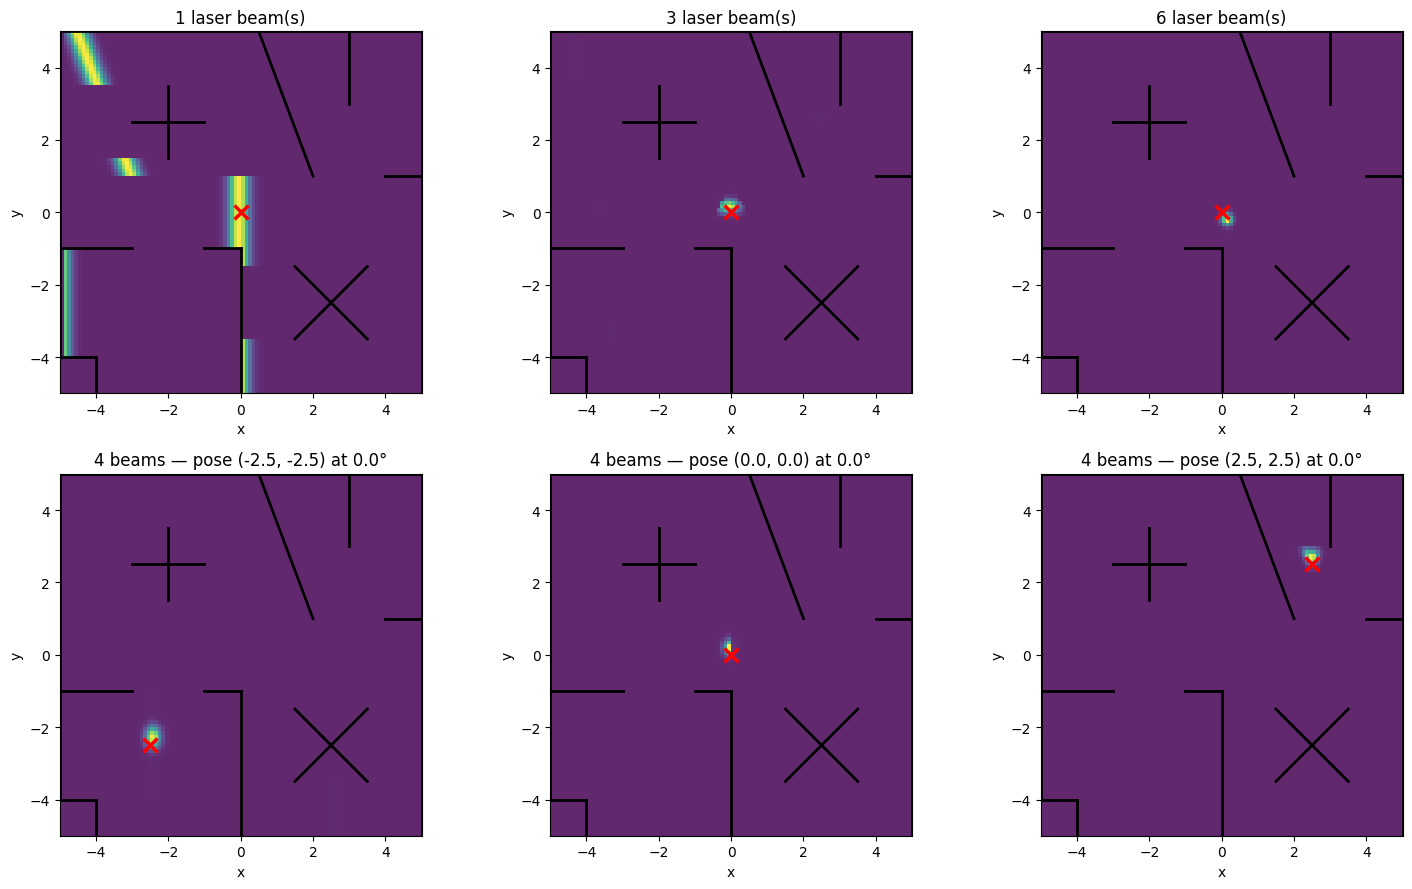

In [30]:
plot_beam_range_finder_experiments(
    theta=np.deg2rad(0)
)

In [31]:
# plot_beam_range_finder_experiments(
#     theta=np.deg2rad(45)
# )

### Results and Discussion

The Beam Range Finder Model was implemented by combining **ray casting** with the probabilistic sensor model. For each candidate robot pose, the expected range of every laser beam is first computed from the map using ray casting. The observed measurements are then evaluated using the four components of the sensor model:

$$
p(z_t^k \mid x_t,m)
=
z_{\mathrm{hit}}p_{\mathrm{hit}}
+
z_{\mathrm{short}}p_{\mathrm{short}}
+
z_{\mathrm{max}}p_{\mathrm{max}}
+
z_{\mathrm{rand}}p_{\mathrm{rand}}.
$$

Assuming conditional independence between the individual beams, the likelihood of the complete scan is obtained as

$$
p(z_t\mid x_t,m)
=
\prod_{k=1}^{K}
p(z_t^k\mid x_t,m).
$$

This likelihood was evaluated over a grid of candidate robot positions, producing a **likelihood map**. Bright regions correspond to poses that are more compatible with the observed laser measurements, while darker regions correspond to poses that provide a poorer explanation of the scan.

#### Effect of the Number of Laser Beams

The first row compares the likelihood distribution for a fixed robot pose using **1, 3, and 6 laser beams**.

With only **one beam**, the probability distribution is highly elongated and contains several regions of high likelihood. This is expected because a single range measurement provides very limited geometric information. Many different robot positions can produce approximately the same distance to an obstacle.

When the number of beams increases to **3**, the distribution becomes considerably more localized. Each additional beam introduces another geometric constraint, and the intersection of these constraints reduces the number of poses that are consistent with the complete observation.

With **6 beams**, the distribution becomes even more concentrated around the true pose. The multiple measurements observe different parts of the environment, providing a stronger geometric signature for the robot location.

Therefore, the experiment illustrates the relationship

$$
\boxed{
\text{more beams}
\;\Rightarrow\;
\text{more geometric constraints}
\;\Rightarrow\;
\text{more localized likelihood}
}
$$

However, the increase in the number of beams does not necessarily produce a perfectly Gaussian or single-peaked distribution. The geometry of the environment can create additional local maxima when different positions produce similar ranges.

<!-- ### Effect of Robot Position

The second row keeps the number of beams fixed at **4** and changes the true robot position.

For the three poses, the high-probability regions move with the robot. This demonstrates that the likelihood distribution is not simply determined by the map itself. Instead, it depends on the relationship between the **observed scan and the geometry of the map from the candidate pose**.

At each candidate position, the algorithm performs ray casting and obtains a different set of expected measurements:

$$
x_t
\rightarrow
\left\{
z_t^{1*},z_t^{2*},\ldots,z_t^{K*}
\right\}.
$$

The candidate pose receives a high likelihood when these expected measurements are compatible with the observed scan.

Consequently, changing the true robot position changes the observed geometric configuration and therefore changes the shape and location of the likelihood distribution.

### Effect of Robot Orientation

The second set of plots also illustrates the effect of changing the robot orientation from $0^\circ$ to $30^\circ$.

When the orientation changes, the laser beams rotate with the robot. Therefore, even though the robot may remain at the same position, the beams intersect different parts of the environment. The expected measurements consequently change:

$$
z_t^{k*}
=
\operatorname{RayCast}
\left(
x_t,\theta_t+\theta_k
\right).
$$

The resulting likelihood maps are therefore different from those obtained with a $0^\circ$ orientation.

This effect is particularly visible when using fewer beams. With only one beam, rotating the sensor changes the direction of the single geometric constraint, producing a substantially different elongated likelihood region. With more beams, the set of constraints becomes richer and the distribution becomes more spatially selective.

### Comparison of the Two Experiments

The two experiments demonstrate two complementary properties of the Beam Range Finder Model:

| Experiment | Variable | Main observation |
|---|---|---|
| First row | Number of beams | More beams provide more geometric constraints and generally produce a more localized likelihood |
| Second row | Robot position | The likelihood distribution follows the geometry observed from different positions |
| Orientation comparison | Robot orientation | Rotating the robot changes the beam directions and therefore changes the likelihood distribution | -->

Overall, the results show that the Beam Range Finder Model effectively transforms laser measurements into a spatial likelihood distribution. The **shape of this distribution is determined by the interaction between the sensor observations and the geometry of the map**.

The experiments also highlight an important limitation of sparse range measurements: with few beams, several different poses can explain the same observation. Increasing the number of beams reduces this ambiguity by incorporating more independent geometric constraints.

Thus, the implementation provides an intuitive visualization of the fundamental principle behind scan-based localization:

$$
\boxed{
\text{candidate pose}
\rightarrow
\text{ray casting}
\rightarrow
\text{expected measurements}
\rightarrow
\text{sensor likelihood}
\rightarrow
\text{pose likelihood map}
}
$$

## Algorithm learning intrinsic paramters

### Learning the Intrinsic Sensor Parameters

The Beam Range Finder Model depends on several **intrinsic parameters** that describe the characteristics of the range sensor:

$$
\Theta =
\{
z_{\mathrm{hit}},
z_{\mathrm{short}},
z_{\mathrm{max}},
z_{\mathrm{rand}},
\sigma_{\mathrm{hit}},
\lambda_{\mathrm{short}}
\}.
$$

In practice, these parameters may not be known beforehand and must be estimated from sensor measurements. The objective of the `learn_intrinsic_parameters` algorithm is therefore to learn the parameters $\Theta$ from a dataset of observations $Z$, the corresponding robot poses $X$, and the map $m$.

The main difficulty is that, although the complete measurement $z_i$ is observed, we do not know **which component of the sensor model generated it**. A measurement close to the expected range may have been generated by the `hit` component, while an unexpectedly short measurement may have been generated by `short`, for example.

The algorithm therefore assigns each observation a degree of responsibility for each component. For a measurement $z_i$, the responsibilities are computed as:

$$
e_{i,\mathrm{hit}},
\quad
e_{i,\mathrm{short}},
\quad
e_{i,\mathrm{max}},
\quad
e_{i,\mathrm{rand}}.
$$

These values represent how strongly each component explains the observation.

The algorithm then uses these responsibilities to update the parameters of the mixture. The mixture weights are obtained from the average responsibility assigned to each component:

$$
z_{\mathrm{hit}}
=
\frac{1}{|Z|}
\sum_i e_{i,\mathrm{hit}},
$$

and analogously for the `short`, `max`, and `rand` components.

The parameters $\sigma_{\mathrm{hit}}$ and $\lambda_{\mathrm{short}}$ are also updated using weighted maximum-likelihood estimates. Therefore, observations that are more strongly associated with a particular component have a greater influence on the estimation of that component's parameters.

### Algorithm

The complete procedure is summarized by the following pseudocode:

```text
Algorithm learn_intrinsic_parameters(Z, X, m):

    repeat until convergence:

        for all measurements zi in Z:

            compute the expected measurement zi*

            compute the responsibilities:
                ei,hit
                ei,short
                ei,max
                ei,rand

        update:
            z_hit
            z_short
            z_max
            z_rand
            sigma_hit
            lambda_short

    return Θ
```
The algorithm can therefore be understood as an iterative process:

$$
\boxed{
\text{measurements}
\rightarrow
\text{responsibilities}
\rightarrow
\text{parameter updates}
\rightarrow
\text{new responsibilities}
\rightarrow
\cdots
}
$$

The iterations continue until the estimated parameters stop changing significantly, indicating convergence.

This procedure is closely related to the **Expectation-Maximization (EM)** framework. The responsibility calculation corresponds to the **Expectation step**, where the algorithm estimates how likely each component is to have generated each measurement. The parameter updates correspond to the **Maximization step**, where the model parameters are re-estimated using these responsibilities.

In the following experiment, synthetic measurements are generated using known sensor parameters. The learning algorithm is then given the measurements without being told which component generated each observation. The learned parameters can subsequently be compared with the known ground-truth parameters to evaluate how well the algorithm recovers the sensor characteristics.

In [32]:
def run_parameter_learning_experiment(
    obstacle_map,
    beam_angles,
    n_poses,
    min_distance=0.2,
    seed=42,
    z_max=10.0,
    z_hit_true=0.7,
    z_short_true=0.1,
    z_max_true=0.1,
    z_rand_true=0.1,
    sigma_hit_true=0.2,
    lambda_short_true=1.0,
    max_iterations=100,
    tolerance=1e-5
):
    """
    Generate a synthetic dataset and learn the sensor parameters
    using the EM algorithm.
    """

    # Generate valid robot poses
    poses = generate_random_poses(
        obstacle_map=obstacle_map,
        n_poses=n_poses,
        min_distance=min_distance,
        seed=seed
    )

    # Generate synthetic measurements
    scans, expected, components = generate_synthetic_dataset(
        poses=poses,
        obstacle_map=obstacle_map,
        beam_angles=beam_angles,

        z_max=z_max,

        z_hit=z_hit_true,
        z_short=z_short_true,
        z_max_weight=z_max_true,
        z_rand=z_rand_true,

        sigma_hit=sigma_hit_true,
        lambda_short=lambda_short_true,

        seed=seed
    )

    # Learn parameters using EM
    learned_parameters = learn_intrinsic_parameters(
        scans=scans,
        poses=poses,
        obstacle_map=obstacle_map,
        beam_angles=beam_angles,

        z_max=z_max,

        # Initial parameters
        z_hit=0.25,
        z_short=0.25,
        z_max_weight=0.25,
        z_rand=0.25,

        sigma_hit=0.5,
        lambda_short=0.5,

        max_iterations=max_iterations,
        tolerance=tolerance
    )

    true_parameters = {
        "z_hit": z_hit_true,
        "z_short": z_short_true,
        "z_max_weight": z_max_true,
        "z_rand": z_rand_true,
        "sigma_hit": sigma_hit_true,
        "lambda_short": lambda_short_true
    }


    print(f"Number of poses: {n_poses}")
    print(f"Number of measurements: {n_poses * len(beam_angles)}")

    print("\nTrue parameters:")

    for name, value in true_parameters.items():
        print(f"{name:<15} = {value}")

    print("\nLearned parameters:")
    for name, value in learned_parameters.items():
        print(f"{name:<15} = {value}")

    return {
        "poses": poses,
        "scans": scans,
        "expected": expected,
        "components": components,
        "true_parameters": true_parameters,
        "learned_parameters": learned_parameters
    }

In [33]:
# 100 poses, 8 beams
(   obstacle_map,
    beam_angles,
    z_expected,
    z,
    x_values,
    y_values,
    pose_true
    ) = create_features(
    n_beams=8,
    z_max=z_max,
    sigma_sensor=sigma_sensor,
    seed=42,
    x_true=(0.0, 0.0),
    theta_true=0.0
)

In [34]:
results_learned_exp1 = run_parameter_learning_experiment(
    obstacle_map=obstacle_map,
    beam_angles=beam_angles,
    n_poses=100
)

Convergence reached at iteration 23.
Number of poses: 100
Number of measurements: 800

True parameters:
z_hit           = 0.7
z_short         = 0.1
z_max_weight    = 0.1
z_rand          = 0.1
sigma_hit       = 0.2
lambda_short    = 1.0

Learned parameters:
z_hit           = 0.7264192779205141
z_short         = 0.07599709833802269
z_max_weight    = 0.0749963565460442
z_rand          = 0.12258726719541901
sigma_hit       = 0.18609866642035128
lambda_short    = 1.5338441879144447


### Analysis of the Results

The algorithm was executed on a set of synthetic measurements generated from the map, using 8 beams per pose. Convergence was reached at the **23rd iteration**, indicating that the parameters stabilized according to the chosen convergence criterion.

| Parameter | True Value | Learned Value |
|---|---:|---:|
| $z_{hit}$ | 0.700 | 0.726 |
| $z_{short}$ | 0.100 | 0.076 |
| $z_{max}$ | 0.100 | 0.075 |
| $z_{rand}$ | 0.100 | 0.123 |
| $\sigma_{hit}$ | 0.200 | 0.186 |
| $\lambda_{short}$ | 1.000 | 1.534 |

The **mixture weights** were recovered reasonably close to the values used to generate the data. The `hit` component remains the dominant component, with a learned weight of $0.726$, compared to the true value of $0.7$. The `short`, `max`, and `rand` components also remained close to $0.1$. These small differences are expected because the measurements are randomly generated, and some observations may be reasonably explained by more than one component.

The parameter $\sigma_{hit}$ was also estimated accurately. The learned value of $0.186$ is close to the true value of $0.2$, indicating that the algorithm was able to estimate the dispersion of the noise associated with measurements close to the expected range.

The largest difference occurs for $\lambda_{short}$, which was estimated as $1.534$, while the value used to generate the data was $1.0$. A possible explanation is the way the `short` component was modeled: the measurements are generated using a **truncated exponential distribution**, whereas the estimator used in the maximization step corresponds to the simplified form of the exponential distribution. Therefore, there is a difference between the distribution used to generate the measurements and the expression used to estimate $\lambda_{short}$.

Despite these differences, the results show that the procedure is able to **approximately recover the model parameters from the measurements** and converge after a finite number of iterations. The observed discrepancies also illustrate that the quality of the parameter estimation depends both on the amount of available data and on the consistency between the probabilistic model used to generate the measurements and the model used during the learning process.

In [35]:
# 1000 poses, 8 beams
results_learned_exp2 = run_parameter_learning_experiment(
    obstacle_map=obstacle_map,
    beam_angles=beam_angles,
    n_poses=1000
)

Convergence reached at iteration 25.
Number of poses: 1000
Number of measurements: 8000

True parameters:
z_hit           = 0.7
z_short         = 0.1
z_max_weight    = 0.1
z_rand          = 0.1
sigma_hit       = 0.2
lambda_short    = 1.0

Learned parameters:
z_hit           = 0.7129199943613447
z_short         = 0.08510051403895129
z_max_weight    = 0.0735317092346066
z_rand          = 0.12844778236510532
sigma_hit       = 0.18812355220292779
lambda_short    = 1.7586560874240502


### Analysis of the Learned Parameters

The learning procedure was evaluated using a larger synthetic dataset containing **1000 robot poses and 8 range measurements per pose**, resulting in a total of 8000 observations.

| Parameter | True Value | Learned Value |
|---|---:|---:|
| $z_{hit}$ | 0.700 | 0.713 |
| $z_{short}$ | 0.100 | 0.085 |
| $z_{max}$ | 0.100 | 0.074 |
| $z_{rand}$ | 0.100 | 0.128 |
| $\sigma_{hit}$ | 0.200 | 0.188 |
| $\lambda_{short}$ | 1.000 | 1.759 |

The learned **mixture weights** are relatively close to the true values. In particular, the `hit` component remains the dominant component, with a learned weight of $0.713$ compared to the true value of $0.7$. The other components show moderate deviations, with some probability mass being redistributed between the `short`, `max`, and `rand` components.

The estimate of $\sigma_{hit}$ is also close to the true value. The learned value of $0.188$ compared to $0.2$ indicates that the algorithm successfully captures the dispersion of measurements generated around the expected range.

However, $\lambda_{short}$ presents a significantly larger discrepancy. Its learned value of $1.759$ is considerably higher than the true value of $1.0$. Increasing the dataset size from 800 to 8000 measurements did not remove this discrepancy. This suggests that the difference is not primarily caused by insufficient data.

A likely explanation is the difference between the **distribution used to generate the synthetic measurements** and the **estimator used during the maximization step**. The synthetic `short` measurements are generated using a truncated exponential distribution, while the implemented update for $\lambda_{short}$ uses the estimator

$$
\lambda_{short}
=
\frac{\sum_i e_{i,short}}
{\sum_i e_{i,short}z_i},
$$

which corresponds to the standard, non-truncated exponential distribution. Therefore, even with a large number of observations, the learned value of $\lambda_{short}$ is not expected to necessarily converge to the value used to generate the data.

Overall, the results demonstrate that the EM procedure is able to recover the main characteristics of the sensor model. The mixture weights and $\sigma_{hit}$ are estimated consistently, while the behavior of $\lambda_{short}$ highlights the importance of using a consistent probabilistic model during both data generation and parameter estimation.

## Likelihood Field Range Finder Model

The **Likelihood Field Range Finder Model** is an alternative sensor model for evaluating how well a laser scan is explained by a candidate robot pose and a known map.

Unlike the **Beam Range Finder Model**, which explicitly compares each measured range $z_t^k$ with an expected range $z_t^{k*}$ obtained through ray casting, the Likelihood Field Model evaluates the **endpoint of each laser measurement** and determines how close that endpoint is to an obstacle in the map.

For a candidate pose $x_t$, the endpoint of beam $k$ is computed from the measured range and the beam direction:

$$
x_{z_t^k}
=
x + x_{k,\mathrm{sens}}\cos\theta
- y_{k,\mathrm{sens}}\sin\theta
+ z_t^k\cos(\theta+\theta_{k,\mathrm{sens}})
$$

$$
y_{z_t^k}
=
y + y_{k,\mathrm{sens}}\cos\theta
+ x_{k,\mathrm{sens}}\sin\theta
+ z_t^k\sin(\theta+\theta_{k,\mathrm{sens}})
$$

The distance between this endpoint and the nearest occupied location in the map is then calculated:

$$
\mathrm{dist}
=
\min_{x',y'}
\sqrt{
(x_{z_t^k}-x')^2
+
(y_{z_t^k}-y')^2
}.
$$

The key idea is therefore that a measurement is considered more likely when its endpoint lies **close to an obstacle**. This avoids explicitly requiring the ray casting procedure to identify the exact obstacle that generated the measurement.

The distance is then converted into a probability using a Gaussian model:

$$
p_{\mathrm{hit}}
=
\mathrm{prob}(\mathrm{dist},\sigma_{\mathrm{hit}})
$$

and a random component is added to account for unexpected measurements:

$$
p(z_t^k\mid x_t,m)
=
z_{\mathrm{hit}}
\,
p_{\mathrm{hit}}(\mathrm{dist},\sigma_{\mathrm{hit}})
+
\frac{z_{\mathrm{rand}}}{z_{\max}}.
$$

The likelihood of the complete scan is obtained by multiplying the probability of each beam:

$$
\boxed{
p(z_t\mid x_t,m)
=
\prod_k
p(z_t^k\mid x_t,m)
}
$$

### Algorithm

The complete procedure can be summarized by the following pseudocode:

```text
Algorithm likelihood_field_range_finder_model(z_t, x_t, m):

    q = 1

    for all k do

        if z_t^k != z_max:

            compute the endpoint (x_zk, y_zk)
            using the robot pose and beam direction

            compute the distance from the endpoint
            to the nearest occupied location in the map

            p =
                z_hit · prob(dist, sigma_hit)
                + z_rand / z_max

            q = q · p

    return q
```
The main difference between the two sensor models can therefore be summarized as follows.

For the **Beam Range Finder Model**, the observed measurement is compared directly with the expected range obtained from ray casting:

$$
\boxed{
\text{Beam Range Finder: }
z_t^k
\rightarrow
z_t^{k*}
\rightarrow
\text{range error}
\rightarrow
p(z_t^k\mid x_t,m)
}
$$

In contrast, the **Likelihood Field Model** does not explicitly calculate the expected range $z_t^{k*}$. Instead, it projects the observed measurement into the map and evaluates the distance between the resulting endpoint and the nearest obstacle:

$$
\boxed{
z_t^k
\rightarrow
\text{measurement endpoint}
\rightarrow
\text{distance to obstacle}
\rightarrow
p(z_t^k\mid x_t,m)
}
$$

This difference makes the Likelihood Field Model particularly convenient when a **distance field** is precomputed for the map. The distance field stores, for each position in the environment, the distance to the nearest obstacle.

Therefore, instead of searching through the map for the nearest obstacle every time a laser measurement is evaluated, the algorithm can simply query the distance field at the measurement endpoint:

$$
\boxed{
\text{measurement endpoint}
\rightarrow
\text{distance field lookup}
\rightarrow
\text{distance to nearest obstacle}
}
$$

This can significantly simplify the computation involved in evaluating the sensor model, especially when the likelihood must be evaluated for a large number of candidate robot poses.

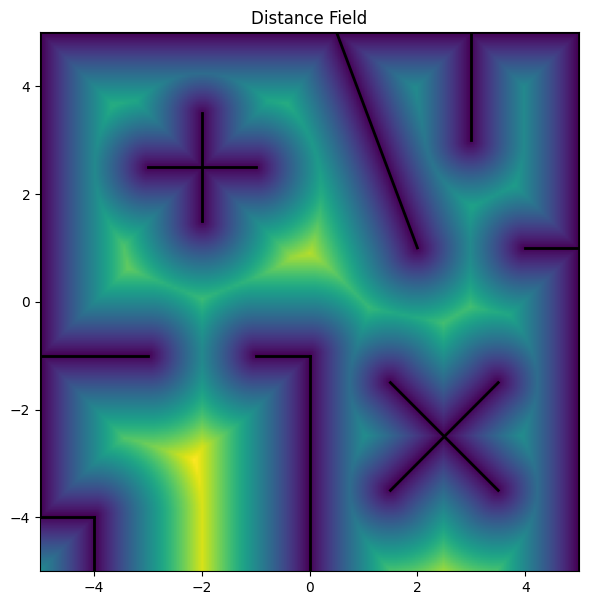

In [36]:
distance_field = DistanceField(
    obstacle_map=obstacle_map,
    resolution=0.05
)

fig, ax = plt.subplots(figsize=(7, 7))
distance_field.draw(ax)

for segment in obstacle_map.segments:
    segment.draw(ax)

ax.set_title("Distance Field")
plt.show()

### Distance Field

The **Distance Field** provides, for each position in the map, the distance to the **nearest obstacle**. Instead of searching for the closest obstacle every time a laser endpoint is evaluated, these distances are precomputed and stored in a grid.

In the visualization, regions close to obstacles have small distance values, while regions farther away have larger values.

Thus, given a laser endpoint $(x,y)$, the Likelihood Field Model can simply query the distance field:

$$
(x,y)
\rightarrow
d_{\mathrm{nearest\ obstacle}}
$$

This distance is then used to compute the likelihood of the measurement. This makes the evaluation of the Likelihood Field Model more efficient, especially when it needs to be evaluated for many candidate robot poses.

In [37]:
def build_likelihood_field_probability_map(
    distance_field,
    z,
    beam_angles,
    x_values,
    y_values,
    z_max,
    z_hit,
    z_rand,
    sigma_hit
):
    probability_map = np.zeros(
        (len(y_values), len(x_values))
    )

    for i, x in enumerate(x_values):

        for j, y in enumerate(y_values):

            pose = Pose(
                x,
                y,
                Angle(0)
            )

            probability_map[j, i] = (
                likelihood_field_range_finder_model(
                    z=z,
                    x=pose,
                    distance_field=distance_field,
                    z_max=z_max,
                    z_hit=z_hit,
                    z_rand=z_rand,
                    sigma_hit=sigma_hit,
                    beam_angles=beam_angles
                )
            )

    return probability_map

In [38]:
def experiment_likelihood_field(
    n_beams=4,
    robot_position=(0.0, 0.0),
    theta=0.0,
    z_max=10.0,
    sigma_sensor=0.2,
    z_hit=0.7,
    z_rand=0.1,
    sigma_hit=0.2,
    resolution=0.05,
    seed=42
):
    """
    Generate and evaluate a likelihood field probability map.
    """

    (
        obstacle_map,
        beam_angles,
        z_expected,
        z,
        x_values,
        y_values,
        pose_true
    ) = create_features(
        n_beams=n_beams,
        x_true=robot_position,
        theta_true=theta,
        z_max=z_max,
        sigma_sensor=sigma_sensor,
        seed=seed
    )

    # Build distance field
    distance_field = DistanceField(
        obstacle_map=obstacle_map,
        resolution=resolution
    )

    # Compute likelihood map
    probability_map = build_likelihood_field_probability_map(
        distance_field=distance_field,
        z=z,
        beam_angles=beam_angles,
        x_values=x_values,
        y_values=y_values,
        z_max=z_max,
        z_hit=z_hit,
        z_rand=z_rand,
        sigma_hit=sigma_hit
    )

    return (
        probability_map,
        obstacle_map,
        distance_field,
        x_values,
        y_values,
        pose_true,
        z,
        beam_angles
    )

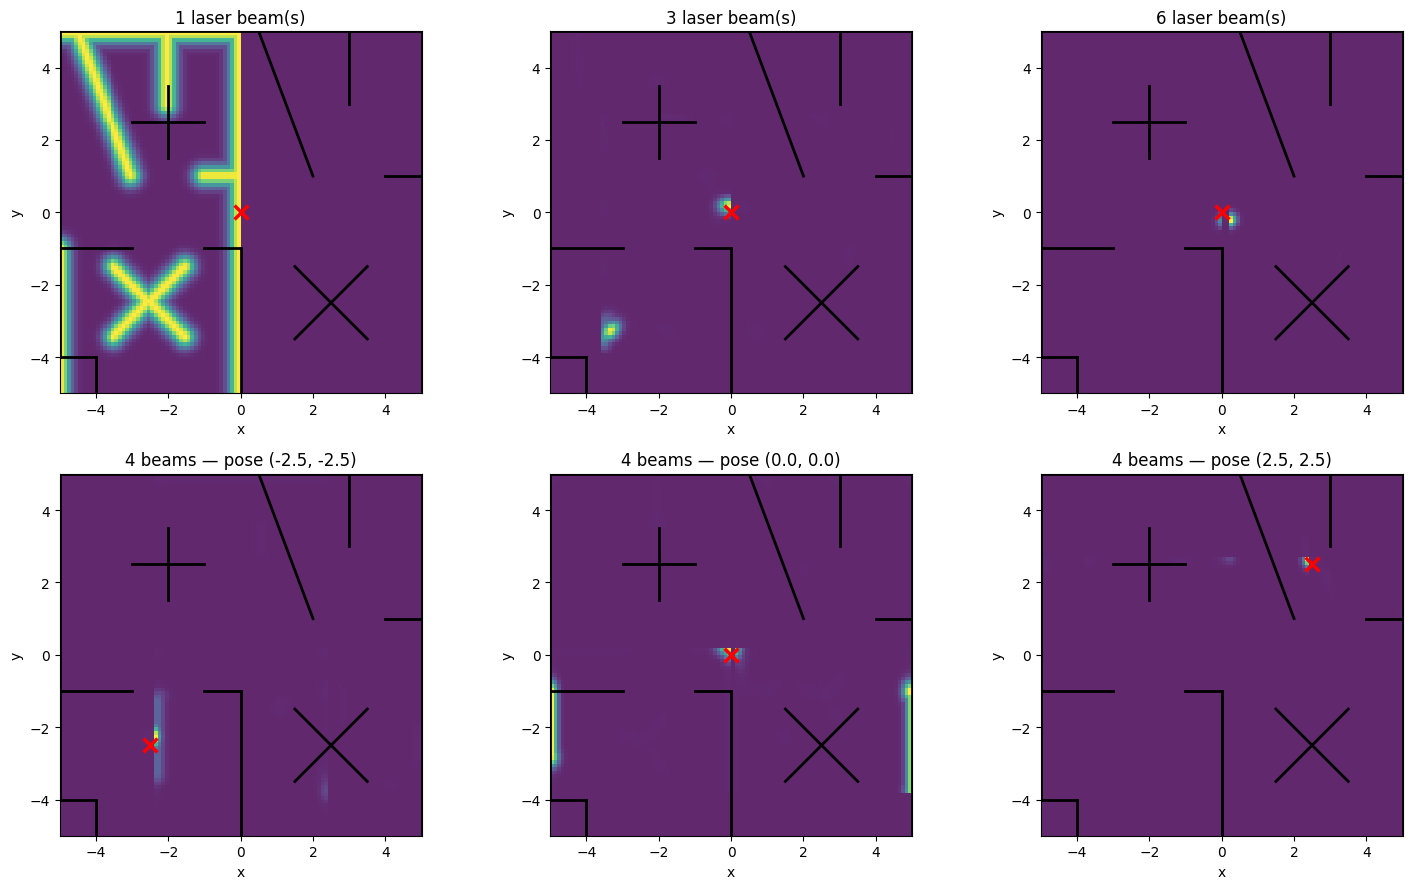

In [39]:
fig, axes = plt.subplots(2, 3,figsize=(15, 9))

# Fixed robot position
beam_experiments = [1, 3, 6]

for ax, n_beams in zip(
    axes[0],
    beam_experiments
):

    (
        probability_map,
        obstacle_map,
        distance_field,
        x_values,
        y_values,
        pose_true,
        z,
        beam_angles
    ) = experiment_likelihood_field(
        n_beams=n_beams,
        robot_position=(0.0, 0.0),
        theta=0.0,
        seed=42
    )

    draw_probability_map_ax(
        ax=ax,
        probability_map=probability_map,
        x_values=x_values,
        y_values=y_values,
        obstacle_map=obstacle_map,
        pose_true=pose_true,
        title=f"{n_beams} laser beam(s)"
    )


# Second row: different robot positions
robot_positions = [
    (-2.5, -2.5),
    (0.0, 0.0),
    (2.5, 2.5)
]
for ax, position in zip(axes[1], robot_positions):

    (
        probability_map,
        obstacle_map,
        distance_field,
        x_values,
        y_values,
        pose_true,
        z,
        beam_angles
    ) = experiment_likelihood_field(
        n_beams=4,
        robot_position=position,
        theta=0.0,
        seed=42
    )

    draw_probability_map_ax(
        ax=ax,
        probability_map=probability_map,
        x_values=x_values,
        y_values=y_values,
        obstacle_map=obstacle_map,
        pose_true=pose_true,
        title=(
            f"4 beams — "
            f"pose ({pose_true.x:.1f}, "
            f"{pose_true.y:.1f})"
        )
    )


plt.tight_layout()
plt.show()

### Results and Discussion — Likelihood Field Model

The **Likelihood Field Model** was implemented using a precomputed distance field. For each candidate robot pose, each laser measurement is projected into the map to obtain its endpoint. The distance from this endpoint to the nearest obstacle is then obtained from the distance field and converted into a probability using the Gaussian hit model.

The likelihood of the complete scan is computed by combining the probabilities of all laser beams:

$$
p(z_t\mid x_t,m)
=
\prod_{k=1}^{K}
p(z_t^k\mid x_t,m).
$$

The resulting likelihood was evaluated over a grid of candidate robot positions, producing the probability maps shown below.

> **Note:** the likelihood field generated by this algorithm is prone to errors when applied without additional criteria. This is most easily visible in the case of a single laser beam. Consider the points of high likelihood in the region $$x \in [-4, -1], y \in [-4, -1]$$. These points show how a measurement that may be completely off for a given location can still yield a high likelihood due to the map's shape. Indeed, this algorithm ignores the closest wall along the ray-tracing path, so the likelihood can be influenced by objects behind the nearest surface to the hypothetical location. This produces high likelihood values that mimic the map's shape of areas that should not be within the robot's line of sight.

#### Effect of the Number of Laser Beams

In the first row, the robot pose is fixed at $(0,0)$ while the number of laser beams is increased from 1 to 3 and 6.

With **one beam**, the likelihood distribution is highly ambiguous. Several elongated regions of high probability appear along the obstacles in the map. This is expected because the Likelihood Field Model evaluates whether the endpoint of the measured beam is close to an obstacle. With only one measurement, many different robot poses can place the endpoint near an obstacle.

With **three beams**, the likelihood distribution becomes considerably more localized. A candidate pose must simultaneously place multiple measurement endpoints near obstacles, making it more difficult for unrelated poses to explain the complete scan.

With **six beams**, the distribution becomes even more selective, with most of the probability concentrated around a smaller number of regions.

Therefore, the experiment demonstrates that increasing the number of beams provides additional geometric constraints:

$$
K \uparrow
\quad\Rightarrow\quad
\text{more measurement endpoints}
\quad\Rightarrow\quad
\text{more geometric constraints}
\quad\Rightarrow\quad
\text{less ambiguity}.
$$

However, increasing the number of beams does not necessarily guarantee a single maximum. Different locations in a structured environment may still produce similar endpoint configurations.

#### Effect of Robot Position

In the second row, the number of beams is fixed at four while the robot position is changed between $(-2.5,-2.5)$, $(0,0)$, and $(2.5,2.5)$.

The likelihood distribution changes with the robot position because the same sensor configuration observes different parts of the environment from each pose. Consequently, the measured scan produces different endpoint locations relative to the map.

For each candidate pose, the model effectively performs:

$$
z_t^k
\rightarrow
\text{measurement endpoint}
\rightarrow
\text{distance to nearest obstacle}
\rightarrow
p(z_t^k\mid x_t,m).
$$

The complete scan is therefore likely when **multiple endpoints are simultaneously close to obstacles**.

The results show that the regions of high likelihood move according to the geometry observed from each robot position. The true pose, indicated by the red cross, is generally located close to a high-likelihood region.

#### Comparison with the Beam Range Finder Model

The experiments also highlight the fundamental difference between the two sensor models.

The **Beam Range Finder Model** explicitly compares the observed measurement with the expected range obtained through ray casting:

$$
z_t^k
\rightarrow
z_t^{k*}
\rightarrow
\text{range error}
\rightarrow
p(z_t^k\mid x_t,m).
$$

The **Likelihood Field Model**, on the other hand, evaluates the distance between the measurement endpoint and the nearest obstacle:

$$
z_t^k
\rightarrow
\text{measurement endpoint}
\rightarrow
\text{distance to obstacle}
\rightarrow
p(z_t^k\mid x_t,m).
$$

This difference explains the characteristic elongated regions observed in the one-beam Likelihood Field result. The model does not explicitly require a candidate pose to predict the exact measured range. Instead, it rewards poses for which the measurement endpoints fall close to occupied regions of the map.

With additional beams, several endpoint constraints must be satisfied simultaneously, which substantially reduces this ambiguity.

#### Influence of Measurement Noise

The measurements used in the experiment contain sensor noise. Therefore, the observed scan is not necessarily identical to the ideal measurements predicted by the map:

$$
z_t^k = z_t^{k*} + \epsilon.
$$

As a consequence, the maximum likelihood pose does not necessarily coincide exactly with the true pose. A nearby candidate pose may produce endpoints that happen to be slightly closer to the obstacles for that particular noisy scan.

Thus, a small displacement between the red cross and the maximum of the likelihood distribution does not necessarily indicate an implementation error. It is a consequence of estimating the pose from noisy measurements.

#### Overall Interpretation

The experiments demonstrate the main behavior expected from the Likelihood Field Model:

$$
\boxed{
\text{candidate pose}
\rightarrow
\text{measurement endpoints}
\rightarrow
\text{distance field}
\rightarrow
\text{beam probabilities}
\rightarrow
p(z_t\mid x_t,m)
}
$$

The results show that a small number of beams can leave considerable positional ambiguity, while increasing the number of beams provides more geometric constraints and generally produces a more localized likelihood distribution.

The experiments also illustrate why the **distance field** is useful for this model: instead of explicitly searching for the nearest obstacle for every measurement and every candidate pose, the distance to the nearest obstacle can be efficiently obtained through a lookup in the precomputed distance field.